In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import MinMaxScaler

from scipy.sparse import csr_matrix

import joblib
import os


In [4]:
master = pd.read_csv(
    "../data/processed/tourism_master_cleaned.csv"
)

print("Dataset shape:", master.shape)

display(master.head())

Dataset shape: (52930, 27)


,transactionid,userid,visityear,visitmonth,visitmode,attractionid,rating,user_continentid,user_regionid,user_countryid,user_cityid,user_cityname,user_city_countryid,user_country,user_country_regionid,user_region,user_region_continentid,user_continent,attractioncityid,attractiontypeid,attraction,attractionaddress,attractiontype,attraction_cityname,attraction_countryid,attraction_country,attraction_regionid
0,3,70456,2022,10,2,640,5,5,21,163,4341.0,Guildford,109.0,United Kingdom,21,Western Europe,5,Europe,1,63,Sacred Monkey Forest Sanctuary,"Jl. Monkey Forest, Ubud 80571 Indonesia",Nature & Wildlife Areas,Douala,1,Cameroon,1
1,8,7567,2022,10,4,640,5,2,8,48,464.0,Ontario,48.0,Canada,8,Northern America,2,America,1,63,Sacred Monkey Forest Sanctuary,"Jl. Monkey Forest, Ubud 80571 Indonesia",Nature & Wildlife Areas,Douala,1,Cameroon,1
2,9,79069,2022,10,3,640,5,2,9,54,774.0,Brazil,51.0,Brazil,9,South America,2,America,1,63,Sacred Monkey Forest Sanctuary,"Jl. Monkey Forest, Ubud 80571 Indonesia",Nature & Wildlife Areas,Douala,1,Cameroon,1
3,10,31019,2022,10,3,640,3,5,17,135,583.0,Zurich,48.0,Switzerland,17,Central Europe,5,Europe,1,63,Sacred Monkey Forest Sanctuary,"Jl. Monkey Forest, Ubud 80571 Indonesia",Nature & Wildlife Areas,Douala,1,Cameroon,1
4,15,43611,2022,10,2,640,3,5,21,163,1396.0,Manchester,51.0,United Kingdom,21,Western Europe,5,Europe,1,63,Sacred Monkey Forest Sanctuary,"Jl. Monkey Forest, Ubud 80571 Indonesia",Nature & Wildlife Areas,Douala,1,Cameroon,1


In [5]:
recommendation_data = master[
    [
        "userid",
        "attractionid",
        "attraction",
        "attractiontypeid",
        "attractiontype",
        "attractioncityid",
        "attraction_cityname",
        "attraction_countryid",
        "attraction_country",
        "rating"
    ]
].copy()

print(
    "Recommendation dataset shape:",
    recommendation_data.shape
)

print(
    "Unique users:",
    recommendation_data["userid"].nunique()
)

print(
    "Unique attractions:",
    recommendation_data["attractionid"].nunique()
)

Recommendation dataset shape: (52930, 10)
Unique users: 33530
Unique attractions: 30


In [6]:
user_item_stats = recommendation_data.groupby(
    "userid"
).agg(
    unique_attractions=("attractionid", "nunique"),
    transaction_count=("attractionid", "count"),
    average_rating=("rating", "mean")
)

display(
    user_item_stats.describe()
)

,unique_attractions,transaction_count,average_rating
count,33530.000000,33530.000000,33530.000000
mean,1.350283,1.578586,4.167413
std,0.763066,1.316680,0.915425
min,1.000000,1.000000,1.000000
25%,1.000000,1.000000,4.000000
50%,1.000000,1.000000,4.000000
75%,1.000000,2.000000,5.000000
max,10.000000,59.000000,5.000000


In [7]:
print(
    "Users with only 1 attraction:",
    (user_item_stats["unique_attractions"] == 1).sum()
)

print(
    "Users with more than 1 attraction:",
    (user_item_stats["unique_attractions"] > 1).sum()
)

Users with only 1 attraction: 25596
Users with more than 1 attraction: 7934


In [8]:
attraction_stats = recommendation_data.groupby(
    ["attractionid", "attraction"]
).agg(
    visit_count=("userid", "count"),
    unique_users=("userid", "nunique"),
    average_rating=("rating", "mean"),
    rating_std=("rating", "std")
).reset_index()

attraction_stats = attraction_stats.sort_values(
    "visit_count",
    ascending=False
)

display(attraction_stats)

,attractionid,attraction,visit_count,unique_users,average_rating,rating_std
2,640,Sacred Monkey Forest Sanctuary,13198,11487,4.267086,0.873768
9,841,Waterbom Bali,6429,5605,4.646601,0.642447
6,748,Tegalalang Rice Terrace,5815,5415,4.157524,0.948421
8,824,Uluwatu Temple,3359,3183,4.219411,0.883859
5,737,Tanah Lot Temple,3352,3156,4.194809,0.908823
3,650,Sanur Beach,3044,2808,3.976347,0.981642
4,673,Seminyak Beach,2914,2754,3.800618,1.125670
0,369,Kuta Beach - Bali,2765,2571,3.415190,1.288006
23,1171,Merapi Volcano,2235,855,4.079195,0.942145
7,749,Tegenungan Waterfall,2190,2152,3.895434,0.994515


In [9]:
user_item_matrix = recommendation_data.pivot_table(
    index="userid",
    columns="attractionid",
    values="rating",
    aggfunc="mean"
)

print(
    "User-item matrix shape:",
    user_item_matrix.shape
)

display(user_item_matrix.head())

User-item matrix shape: (33530, 30)


attractionid,369,481,640,650,673,737,748,749,824,841,877,888,897,913,920,928,937,947,949,975,1133,1137,1166,1171,1220,1225,1238,1278,1280,1297
userid,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
14,NaN,NaN,4.00,NaN,NaN,NaN,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
16,NaN,5.0,4.25,NaN,NaN,NaN,5.0,NaN,5.0,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
23,NaN,NaN,NaN,NaN,NaN,NaN,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [10]:
total_cells = (
    user_item_matrix.shape[0]
    * user_item_matrix.shape[1]
)

observed_cells = user_item_matrix.notna().sum().sum()

sparsity = (
    1 - observed_cells / total_cells
) * 100

print(
    f"Observed ratings: {observed_cells:,}"
)

print(
    f"Total possible interactions: {total_cells:,}"
)

print(
    f"Matrix sparsity: {sparsity:.2f}%"
)

Observed ratings: 45,275
Total possible interactions: 1,005,900
Matrix sparsity: 95.50%


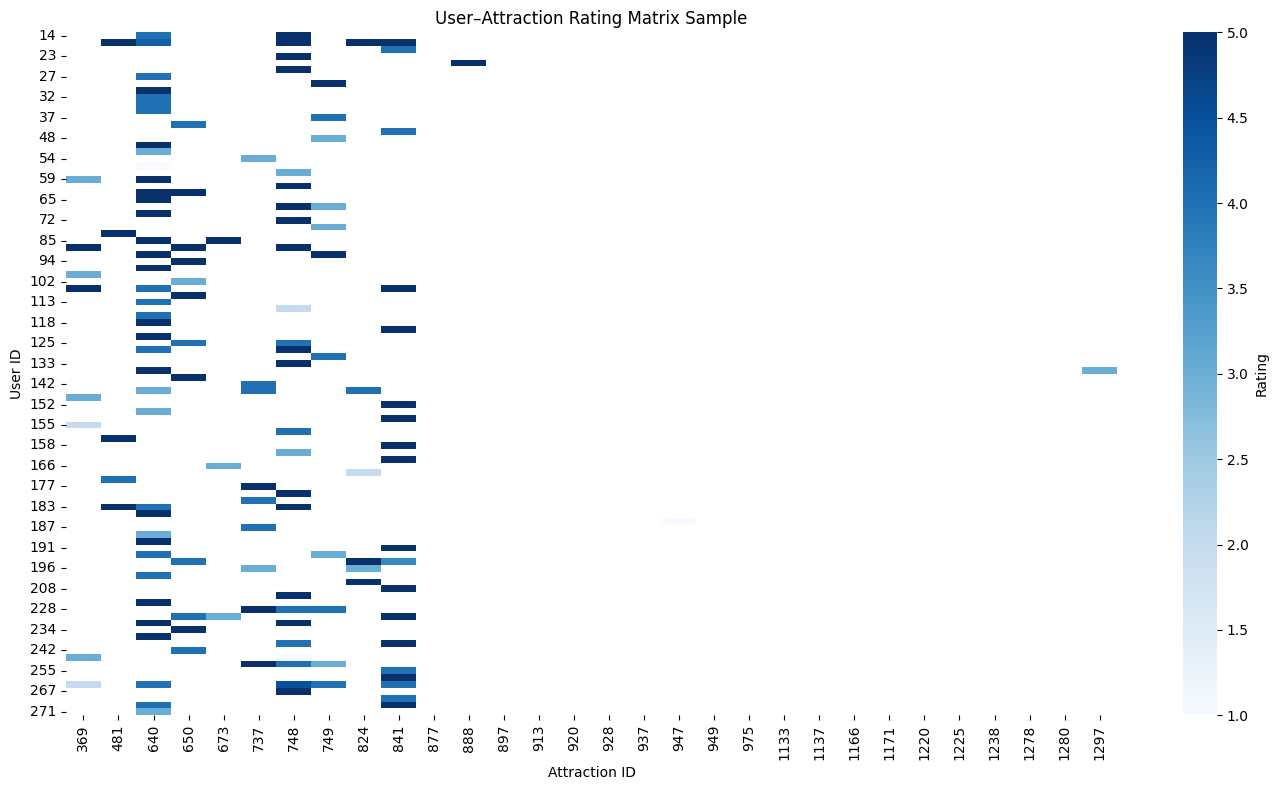

In [11]:
matrix_sample = user_item_matrix.head(100)

plt.figure(figsize=(14, 8))

sns.heatmap(
    matrix_sample,
    cmap="Blues",
    cbar_kws={
        "label": "Rating"
    }
)

plt.title(
    "User–Attraction Rating Matrix Sample"
)

plt.xlabel("Attraction ID")
plt.ylabel("User ID")

plt.tight_layout()
plt.show()

In [12]:
attraction_lookup = (
    recommendation_data[
        [
            "attractionid",
            "attraction",
            "attractiontype",
            "attraction_cityname",
            "attraction_country"
        ]
    ]
    .drop_duplicates("attractionid")
    .set_index("attractionid")
)

display(attraction_lookup.head())

,attraction,attractiontype,attraction_cityname,attraction_country
attractionid,,,,
640,Sacred Monkey Forest Sanctuary,Nature & Wildlife Areas,Douala,Cameroon
841,Waterbom Bali,Water Parks,Douala,Cameroon
673,Seminyak Beach,Beaches,Douala,Cameroon
481,Nusa Dua Beach,Beaches,Douala,Cameroon
650,Sanur Beach,Beaches,Douala,Cameroon


In [13]:
print(
    "Attraction lookup rows:",
    len(attraction_lookup)
)

Attraction lookup rows: 30


In [14]:
popularity_baseline = (
    recommendation_data
    .groupby(["attractionid", "attraction"])
    .agg(
        interaction_count=("userid", "count"),
        average_rating=("rating", "mean")
    )
    .reset_index()
)

In [15]:
C = popularity_baseline["average_rating"].mean()

m = popularity_baseline["interaction_count"].quantile(0.50)

popularity_baseline["weighted_score"] = (
    (
        popularity_baseline["interaction_count"]
        /
        (
            popularity_baseline["interaction_count"] + m
        )
    )
    * popularity_baseline["average_rating"]
    +
    (
        m
        /
        (
            popularity_baseline["interaction_count"] + m
        )
    )
    * C
)

In [16]:
popularity_baseline = popularity_baseline.sort_values(
    "weighted_score",
    ascending=False
)

display(
    popularity_baseline.head(10)
)

,attractionid,attraction,interaction_count,average_rating,weighted_score
9,841,Waterbom Bali,6429,4.646601,4.616359
11,888,Bromo Tengger Semeru National Park,381,4.611549,4.358123
2,640,Sacred Monkey Forest Sanctuary,13198,4.267086,4.262516
1,481,Nusa Dua Beach,2104,4.275665,4.249365
27,1278,Ullen Sentalu Museum,978,4.256646,4.213834
17,947,Mount Semeru Volcano,83,4.698795,4.210332
20,1133,Jomblang Cave,135,4.503704,4.208508
8,824,Uluwatu Temple,3359,4.219411,4.207644
5,737,Tanah Lot Temple,3352,4.194809,4.185519
6,748,Tegalalang Rice Terrace,5815,4.157524,4.154209


In [23]:
def popularity_recommendations(
    top_n=5,
    exclude_attractions=None
):

    result = popularity_baseline.copy()

    if exclude_attractions is not None:
        result = result[
            ~result["attractionid"].isin(exclude_attractions)
        ]

    return (
        result[
            [
                "attractionid",
                "attraction",
                "average_rating",
                "interaction_count",
                "weighted_score",
            ]
        ]
        .head(top_n)
    )

In [24]:
popularity_recommendations(10)

,attractionid,attraction,average_rating,interaction_count,weighted_score
9,841,Waterbom Bali,4.646601,6429,4.616359
11,888,Bromo Tengger Semeru National Park,4.611549,381,4.358123
2,640,Sacred Monkey Forest Sanctuary,4.267086,13198,4.262516
1,481,Nusa Dua Beach,4.275665,2104,4.249365
27,1278,Ullen Sentalu Museum,4.256646,978,4.213834
17,947,Mount Semeru Volcano,4.698795,83,4.210332
20,1133,Jomblang Cave,4.503704,135,4.208508
8,824,Uluwatu Temple,4.219411,3359,4.207644
5,737,Tanah Lot Temple,4.194809,3352,4.185519
6,748,Tegalalang Rice Terrace,4.157524,5815,4.154209


In [25]:
attraction_profiles = (
    recommendation_data[
        [
            "attractionid",
            "attraction",
            "attractiontype",
            "attraction_cityname",
            "attraction_country"
        ]
    ]
    .drop_duplicates("attractionid")
    .copy()
)

In [26]:
text_columns = [
    "attraction",
    "attractiontype",
    "attraction_cityname",
    "attraction_country"
]

for column in text_columns:
    attraction_profiles[column] = (
        attraction_profiles[column]
        .fillna("")
        .astype(str)
    )

In [27]:
attraction_profiles["profile"] = (
    attraction_profiles["attraction"]
    + " "
    + attraction_profiles["attractiontype"]
    + " "
    + attraction_profiles["attraction_cityname"]
    + " "
    + attraction_profiles["attraction_country"]
)

In [29]:
display(
    attraction_profiles[
        [
            "attractionid",
            "profile"
        ]
    ].head(10)
)

,attractionid,profile
0,640,Sacred Monkey Forest Sanctuary Nature & Wildli...
13198,841,Waterbom Bali Water Parks Douala Cameroon
19627,673,Seminyak Beach Beaches Douala Cameroon
22541,481,Nusa Dua Beach Beaches Douala Cameroon
24645,650,Sanur Beach Beaches Douala Cameroon
27689,824,Uluwatu Temple Religious Sites Douala Cameroon
31048,748,Tegalalang Rice Terrace Points of Interest & L...
36863,749,Tegenungan Waterfall Waterfalls Douala Cameroon
39053,737,Tanah Lot Temple Religious Sites Douala Cameroon
42405,369,Kuta Beach - Bali Beaches Douala Cameroon


In [30]:
tfidf = TfidfVectorizer(
    stop_words="english"
)

tfidf_matrix = tfidf.fit_transform(
    attraction_profiles["profile"]
)

print(
    "TF-IDF matrix shape:",
    tfidf_matrix.shape
)

TF-IDF matrix shape: (30, 97)


In [31]:
content_similarity = cosine_similarity(
    tfidf_matrix
)

print(
    "Similarity matrix shape:",
    content_similarity.shape
)

Similarity matrix shape: (30, 30)


In [32]:
attraction_index = pd.Series(
    attraction_profiles.index,
    index=attraction_profiles["attractionid"]
).drop_duplicates()

In [33]:
def content_recommendations(
    attraction_id,
    top_n=5
):

    if attraction_id not in attraction_index:
        return pd.DataFrame()

    idx = attraction_index[attraction_id]

    similarity_scores = list(
        enumerate(
            content_similarity[idx]
        )
    )

    similarity_scores = sorted(
        similarity_scores,
        key=lambda x: x[1],
        reverse=True
    )

    similarity_scores = similarity_scores[
        1:top_n + 1
    ]

    indices = [
        x[0]
        for x in similarity_scores
    ]

    result = attraction_profiles.iloc[
        indices
    ].copy()

    result["similarity_score"] = [
        x[1]
        for x in similarity_scores
    ]

    return result[
        [
            "attractionid",
            "attraction",
            "attractiontype",
            "attraction_cityname",
            "attraction_country",
            "similarity_score"
        ]
    ]

In [34]:
top_attraction_id = (
    popularity_baseline
    .iloc[0]["attractionid"]
)

top_attraction_name = (
    popularity_baseline
    .iloc[0]["attraction"]
)

print(
    "Reference attraction:",
    top_attraction_name
)

print(
    "Attraction ID:",
    top_attraction_id
)

Reference attraction: Waterbom Bali
Attraction ID: 841


In [36]:
# Rebuild attraction profiles with a clean 0..n-1 index
attraction_profiles = (
    recommendation_data[
        [
            "attractionid",
            "attraction",
            "attractiontype",
            "attraction_cityname",
            "attraction_country"
        ]
    ]
    .drop_duplicates("attractionid")
    .reset_index(drop=True)
    .copy()
)

# Make sure text columns are strings
for column in text_columns:
    attraction_profiles[column] = (
        attraction_profiles[column]
        .fillna("")
        .astype(str)
    )

# Build content profile
attraction_profiles["profile"] = (
    attraction_profiles["attraction"]
    + " "
    + attraction_profiles["attractiontype"]
    + " "
    + attraction_profiles["attraction_cityname"]
    + " "
    + attraction_profiles["attraction_country"]
)

# Recompute TF-IDF and similarity using the cleaned index
tfidf = TfidfVectorizer(stop_words="english")
tfidf_matrix = tfidf.fit_transform(attraction_profiles["profile"])
content_similarity = cosine_similarity(tfidf_matrix)

# Map attractionid -> row position in the 30x30 similarity matrix
attraction_index = pd.Series(
    attraction_profiles.index,
    index=attraction_profiles["attractionid"]
).drop_duplicates()


def content_recommendations(attraction_id, top_n=5):
    if attraction_id not in attraction_index:
        return pd.DataFrame()

    idx = attraction_index[attraction_id]

    similarity_scores = list(enumerate(content_similarity[idx]))
    similarity_scores = sorted(
        similarity_scores,
        key=lambda x: x[1],
        reverse=True
    )

    similarity_scores = similarity_scores[1:top_n + 1]

    indices = [x[0] for x in similarity_scores]

    result = attraction_profiles.iloc[indices].copy()
    result["similarity_score"] = [x[1] for x in similarity_scores]

    return result[
        [
            "attractionid",
            "attraction",
            "attractiontype",
            "attraction_cityname",
            "attraction_country",
            "similarity_score"
        ]
    ]


content_recommendations(top_attraction_id, top_n=5)

,attractionid,attraction,attractiontype,attraction_cityname,attraction_country,similarity_score
9,369,Kuta Beach - Bali,Beaches,Douala,Cameroon,0.362720
28,1280,Water Castle (Tamansari),Points of Interest & Landmarks,N'Djamena,Chad,0.190644
4,650,Sanur Beach,Beaches,Douala,Cameroon,0.148479
2,673,Seminyak Beach,Beaches,Douala,Cameroon,0.148479
10,888,Bromo Tengger Semeru National Park,National Parks,South Region,Cameroon,0.146109


In [37]:
rating_matrix_filled = user_item_matrix.fillna(0)

print(
    rating_matrix_filled.shape
)

(33530, 30)


In [38]:
rating_sparse = csr_matrix(
    rating_matrix_filled.values
)

print(
    "Sparse matrix shape:",
    rating_sparse.shape
)

Sparse matrix shape: (33530, 30)


In [39]:
item_similarity = cosine_similarity(
    rating_sparse.T
)

print(
    "Item similarity matrix:",
    item_similarity.shape
)

Item similarity matrix: (30, 30)


In [40]:
item_ids = user_item_matrix.columns.tolist()

item_index = {
    item_id: idx
    for idx, item_id in enumerate(item_ids)
}

In [41]:
def collaborative_recommendations(
    user_id,
    top_n=5,
    min_rating=4
):

    if user_id not in user_item_matrix.index:
        return popularity_recommendations(top_n)

    user_ratings = user_item_matrix.loc[user_id]

    liked_items = user_ratings[
        user_ratings >= min_rating
    ].dropna()

    if len(liked_items) == 0:
        return popularity_recommendations(top_n)

    scores = np.zeros(
        len(item_ids)
    )

    for item_id, rating in liked_items.items():

        idx = item_index[item_id]

        scores += (
            item_similarity[idx]
            * rating
        )

    # Don't recommend attractions already rated
    rated_items = user_ratings.dropna().index

    for item_id in rated_items:
        if item_id in item_index:
            scores[
                item_index[item_id]
            ] = -np.inf

    top_indices = np.argsort(
        scores
    )[::-1][:top_n]

    recommended_ids = [
        item_ids[i]
        for i in top_indices
        if scores[i] != -np.inf
    ]

    result = attraction_lookup.loc[
        recommended_ids
    ].copy()

    result["recommendation_score"] = [
        scores[item_index[item_id]]
        for item_id in recommended_ids
    ]

    return result.reset_index()

In [42]:
active_users = (
    user_item_stats[
        user_item_stats["unique_attractions"] >= 3
    ]
    .sort_values(
        "unique_attractions",
        ascending=False
    )
)

test_user_id = active_users.index[0]

print(
    "Test User ID:",
    test_user_id
)

print(
    "Number of attractions:",
    user_item_stats.loc[
        test_user_id,
        "unique_attractions"
    ]
)

Test User ID: 83466
Number of attractions: 10


In [43]:
user_history = recommendation_data[
    recommendation_data["userid"] == test_user_id
][
    [
        "attractionid",
        "attraction",
        "rating"
    ]
].sort_values(
    "rating",
    ascending=False
)

display(user_history)

,attractionid,attraction,rating
13232,841,Waterbom Bali,5
49719,1171,Merapi Volcano,5
49717,1171,Merapi Volcano,5
49729,1171,Merapi Volcano,5
21432,673,Seminyak Beach,4
49722,1171,Merapi Volcano,4
49720,1171,Merapi Volcano,4
29295,824,Uluwatu Temple,4
26446,650,Sanur Beach,4
49737,1171,Merapi Volcano,4


In [44]:
collaborative_recommendations(
    test_user_id,
    top_n=5
)

,attractionid,attraction,attractiontype,attraction_cityname,attraction_country,recommendation_score
0,640,Sacred Monkey Forest Sanctuary,Nature & Wildlife Areas,Douala,Cameroon,2.384286
1,1166,Malioboro Road,Flea & Street Markets,N'Djamena,Chad,0.217322
2,1297,Yogyakarta Palace,Historic Sites,N'Djamena,Chad,0.166972
3,888,Bromo Tengger Semeru National Park,National Parks,South Region,Cameroon,0.153341
4,1238,Sewu Temple,Ancient Ruins,N'Djamena,Chad,0.134388


In [45]:
attraction_metadata_check = (
    recommendation_data[
        [
            "attractionid",
            "attraction",
            "attractiontype",
            "attractioncityid",
            "attraction_cityname",
            "attraction_countryid",
            "attraction_country"
        ]
    ]
    .drop_duplicates("attractionid")
    .sort_values("attractionid")
)

display(attraction_metadata_check)

,attractionid,attraction,attractiontype,attractioncityid,attraction_cityname,attraction_countryid,attraction_country
42405,369,Kuta Beach - Bali,Beaches,1,Douala,1,Cameroon
22541,481,Nusa Dua Beach,Beaches,1,Douala,1,Cameroon
0,640,Sacred Monkey Forest Sanctuary,Nature & Wildlife Areas,1,Douala,1,Cameroon
24645,650,Sanur Beach,Beaches,1,Douala,1,Cameroon
19627,673,Seminyak Beach,Beaches,1,Douala,1,Cameroon
39053,737,Tanah Lot Temple,Religious Sites,1,Douala,1,Cameroon
31048,748,Tegalalang Rice Terrace,Points of Interest & Landmarks,1,Douala,1,Cameroon
36863,749,Tegenungan Waterfall,Waterfalls,1,Douala,1,Cameroon
27689,824,Uluwatu Temple,Religious Sites,1,Douala,1,Cameroon
13198,841,Waterbom Bali,Water Parks,1,Douala,1,Cameroon


In [46]:
item_original = pd.read_excel(
    "../data/raw/Item.xlsx"
)

print("Item shape:", item_original.shape)

display(item_original)

Item shape: (30, 5)


,AttractionId,AttractionCityId,AttractionTypeId,Attraction,AttractionAddress
0,369,1,13,Kuta Beach - Bali,Kuta
1,481,1,13,Nusa Dua Beach,"Semenanjung Nusa Dua, Nusa Dua 80517 Indonesia"
2,640,1,63,Sacred Monkey Forest Sanctuary,"Jl. Monkey Forest, Ubud 80571 Indonesia"
3,650,1,13,Sanur Beach,Sanur
4,673,1,13,Seminyak Beach,Seminyak
5,737,1,76,Tanah Lot Temple,"Kecamatan Kediri, Kabupaten Tabanan, Beraban 8..."
6,748,1,72,Tegalalang Rice Terrace,"Jalan Raya Ceking, Tegalalang 80517 Indonesia"
7,749,1,93,Tegenungan Waterfall,"Jl. Raya Tegenungan, Kemenuh, Ubud 80581 Indon..."
8,824,1,76,Uluwatu Temple,"Jl. Raya Uluwatu Southern part of Bali, Pecatu..."
9,841,1,92,Waterbom Bali,"Jl. Kartika Plaza, Kuta 80361 Indonesia"


In [47]:
updated_item = pd.read_excel(
    "../data/raw/Updated_Item.xlsx"
)

print("Updated Item shape:", updated_item.shape)

display(updated_item.head(30))

Updated Item shape: (1698, 5)


,AttractionId,AttractionCityId,AttractionTypeId,Attraction,AttractionAddress
0,369,1,13,Kuta Beach - Bali,Kuta
1,481,1,13,Nusa Dua Beach,"Semenanjung Nusa Dua, Nusa Dua 80517 Indonesia"
2,640,1,63,Sacred Monkey Forest Sanctuary,"Jl. Monkey Forest, Ubud 80571 Indonesia"
3,650,1,13,Sanur Beach,Sanur
4,673,1,13,Seminyak Beach,Seminyak
5,737,1,76,Tanah Lot Temple,"Kecamatan Kediri, Kabupaten Tabanan, Beraban 8..."
6,748,1,72,Tegalalang Rice Terrace,"Jalan Raya Ceking, Tegalalang 80517 Indonesia"
7,749,1,93,Tegenungan Waterfall,"Jl. Raya Tegenungan, Kemenuh, Ubud 80581 Indon..."
8,824,1,76,Uluwatu Temple,"Jl. Raya Uluwatu Southern part of Bali, Pecatu..."
9,841,1,92,Waterbom Bali,"Jl. Kartika Plaza, Kuta 80361 Indonesia"


In [48]:
transaction_attraction_ids = set(
    master["attractionid"].unique()
)

item_attraction_ids = set(
    item_original["AttractionId"].unique()
)

updated_attraction_ids = set(
    updated_item["AttractionId"].unique()
)

print(
    "Transaction attractions:",
    len(transaction_attraction_ids)
)

print(
    "Item attractions:",
    len(item_attraction_ids)
)

print(
    "Updated Item attractions:",
    len(updated_attraction_ids)
)

print(
    "Transaction IDs missing from Item:",
    transaction_attraction_ids - item_attraction_ids
)

print(
    "Transaction IDs missing from Updated Item:",
    transaction_attraction_ids - updated_attraction_ids
)

Transaction attractions: 30
Item attractions: 30
Updated Item attractions: 1698
Transaction IDs missing from Item: set()
Transaction IDs missing from Updated Item: set()


In [49]:
evaluation_data = recommendation_data[
    [
        "userid",
        "attractionid",
        "rating"
    ]
].copy()

user_interaction_counts = (
    evaluation_data
    .groupby("userid")["attractionid"]
    .nunique()
)

eligible_users = user_interaction_counts[
    user_interaction_counts >= 2
].index

evaluation_data = evaluation_data[
    evaluation_data["userid"].isin(
        eligible_users
    )
].copy()

print(
    "Eligible users:",
    evaluation_data["userid"].nunique()
)

print(
    "Eligible interactions:",
    len(evaluation_data)
)

Eligible users: 7934
Eligible interactions: 23212


In [50]:
np.random.seed(42)

test_indices = (
    evaluation_data
    .groupby("userid", group_keys=False)
    .apply(
        lambda x: x.sample(
            n=1,
            random_state=42
        )
    )
    .index
)

test_interactions = evaluation_data.loc[
    test_indices
].copy()

train_interactions = evaluation_data.drop(
    test_indices
).copy()

print(
    "Training interactions:",
    len(train_interactions)
)

print(
    "Test interactions:",
    len(test_interactions)
)

Training interactions: 15278
Test interactions: 7934


C:\Users\kalav\AppData\Local\Temp\ipykernel_19504\2981502814.py:6: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(


In [51]:
eval_matrix = train_interactions.pivot_table(
    index="userid",
    columns="attractionid",
    values="rating",
    aggfunc="mean"
)

print(
    "Evaluation matrix:",
    eval_matrix.shape
)

Evaluation matrix: (7934, 30)


In [52]:
eval_matrix_filled = eval_matrix.fillna(0)

eval_sparse = csr_matrix(
    eval_matrix_filled.values
)

eval_item_similarity = cosine_similarity(
    eval_sparse.T
)

eval_item_ids = eval_matrix.columns.tolist()

eval_item_index = {
    item_id: idx
    for idx, item_id in enumerate(
        eval_item_ids
    )
}

In [53]:
def evaluate_collaborative_recommendations(
    user_id,
    top_n=5,
    min_rating=4
):

    if user_id not in eval_matrix.index:
        return []

    user_ratings = eval_matrix.loc[user_id]

    liked_items = user_ratings[
        user_ratings >= min_rating
    ].dropna()

    if len(liked_items) == 0:
        return []

    scores = np.zeros(
        len(eval_item_ids)
    )

    for item_id, rating in liked_items.items():

        idx = eval_item_index[item_id]

        scores += (
            eval_item_similarity[idx]
            * rating
        )

    # Remove already seen attractions
    rated_items = user_ratings.dropna().index

    for item_id in rated_items:

        if item_id in eval_item_index:

            scores[
                eval_item_index[item_id]
            ] = -np.inf

    top_indices = np.argsort(
        scores
    )[::-1][:top_n]

    return [
        eval_item_ids[i]
        for i in top_indices
        if scores[i] != -np.inf
    ]

In [54]:
def hit_rate_at_k(
    test_interactions,
    k=5
):

    hits = 0
    total = 0

    for _, row in test_interactions.iterrows():

        user_id = row["userid"]
        actual_item = row["attractionid"]

        recommendations = (
            evaluate_collaborative_recommendations(
                user_id,
                top_n=k
            )
        )

        if actual_item in recommendations:
            hits += 1

        total += 1

    return hits / total if total > 0 else 0

In [55]:
hit5 = hit_rate_at_k(
    test_interactions,
    k=5
)

print(
    "Collaborative Hit Rate@5:",
    round(hit5, 4)
)

Collaborative Hit Rate@5: 0.5374


In [56]:
def precision_at_k(
    test_interactions,
    k=5
):

    total_precision = 0
    evaluated_users = 0

    for _, row in test_interactions.iterrows():

        user_id = row["userid"]
        actual_item = row["attractionid"]

        recommendations = (
            evaluate_collaborative_recommendations(
                user_id,
                top_n=k
            )
        )

        if len(recommendations) == 0:
            continue

        hits = int(
            actual_item in recommendations
        )

        total_precision += (
            hits / len(recommendations)
        )

        evaluated_users += 1

    return (
        total_precision / evaluated_users
        if evaluated_users > 0
        else 0
    )

In [57]:
precision5 = precision_at_k(
    test_interactions,
    k=5
)

print(
    "Collaborative Precision@5:",
    round(precision5, 4)
)

Collaborative Precision@5: 0.1225


In [58]:
def recall_at_k(
    test_interactions,
    k=5
):

    hits = 0
    total = 0

    for _, row in test_interactions.iterrows():

        user_id = row["userid"]
        actual_item = row["attractionid"]

        recommendations = (
            evaluate_collaborative_recommendations(
                user_id,
                top_n=k
            )
        )

        if actual_item in recommendations:
            hits += 1

        total += 1

    return hits / total if total > 0 else 0

In [59]:
recall5 = recall_at_k(
    test_interactions,
    k=5
)

print(
    "Collaborative Recall@5:",
    round(recall5, 4)
)

Collaborative Recall@5: 0.5374


In [61]:
recommendation_metrics = []

for k in [3, 5, 10]:

    hit_rate = hit_rate_at_k(
        test_interactions,
        k=k
    )

    precision = precision_at_k(
        test_interactions,
        k=k
    )

    recall = recall_at_k(
        test_interactions,
        k=k
    )

    recommendation_metrics.append({
        "Model": "Collaborative Filtering",
        "K": k,
        "Hit_Rate": hit_rate,
        "Precision": precision,
        "Recall": recall
    })

recommendation_metrics_df = pd.DataFrame(
    recommendation_metrics
)

display(recommendation_metrics_df)

,Model,K,Hit_Rate,Precision,Recall
0,Collaborative Filtering,3,0.421729,0.160226,0.421729
1,Collaborative Filtering,5,0.537434,0.122511,0.537434
2,Collaborative Filtering,10,0.696874,0.079428,0.696874


In [63]:
# Use only reliable attraction metadata
content_data = (
    recommendation_data[
        [
            "attractionid",
            "attraction",
            "attractiontype"
        ]
    ]
    .drop_duplicates("attractionid")
    .copy()
)

content_data["attraction"] = (
    content_data["attraction"]
    .fillna("")
    .astype(str)
)

content_data["attractiontype"] = (
    content_data["attractiontype"]
    .fillna("")
    .astype(str)
)

# Give attraction name and type slightly different emphasis
content_data["profile"] = (
    content_data["attraction"] + " "
    + content_data["attraction"] + " "
    + content_data["attractiontype"]
)

display(content_data.head(10))

,attractionid,attraction,attractiontype,profile
0,640,Sacred Monkey Forest Sanctuary,Nature & Wildlife Areas,Sacred Monkey Forest Sanctuary Sacred Monkey F...
13198,841,Waterbom Bali,Water Parks,Waterbom Bali Waterbom Bali Water Parks
19627,673,Seminyak Beach,Beaches,Seminyak Beach Seminyak Beach Beaches
22541,481,Nusa Dua Beach,Beaches,Nusa Dua Beach Nusa Dua Beach Beaches
24645,650,Sanur Beach,Beaches,Sanur Beach Sanur Beach Beaches
27689,824,Uluwatu Temple,Religious Sites,Uluwatu Temple Uluwatu Temple Religious Sites
31048,748,Tegalalang Rice Terrace,Points of Interest & Landmarks,Tegalalang Rice Terrace Tegalalang Rice Terrac...
36863,749,Tegenungan Waterfall,Waterfalls,Tegenungan Waterfall Tegenungan Waterfall Wate...
39053,737,Tanah Lot Temple,Religious Sites,Tanah Lot Temple Tanah Lot Temple Religious Sites
42405,369,Kuta Beach - Bali,Beaches,Kuta Beach - Bali Kuta Beach - Bali Beaches


In [64]:
content_tfidf = TfidfVectorizer(
    stop_words="english",
    ngram_range=(1, 2)
)

content_tfidf_matrix = content_tfidf.fit_transform(
    content_data["profile"]
)

print(
    "Content TF-IDF shape:",
    content_tfidf_matrix.shape
)

Content TF-IDF shape: (30, 206)


In [65]:
content_similarity_safe = cosine_similarity(
    content_tfidf_matrix
)

content_item_ids = (
    content_data["attractionid"]
    .tolist()
)

content_item_index = {
    item_id: idx
    for idx, item_id in enumerate(content_item_ids)
}

print(
    "Content similarity matrix:",
    content_similarity_safe.shape
)

Content similarity matrix: (30, 30)


In [66]:
def content_user_recommendations(
    user_id,
    train_matrix,
    top_n=5,
    min_rating=4
):

    if user_id not in train_matrix.index:
        return []

    user_ratings = train_matrix.loc[user_id]

    liked_items = user_ratings[
        user_ratings >= min_rating
    ].dropna()

    if len(liked_items) == 0:
        return []

    scores = np.zeros(
        len(content_item_ids)
    )

    total_weight = 0

    for item_id, rating in liked_items.items():

        if item_id not in content_item_index:
            continue

        idx = content_item_index[item_id]

        weight = float(rating)

        scores += (
            content_similarity_safe[idx]
            * weight
        )

        total_weight += weight

    if total_weight > 0:
        scores = scores / total_weight

    # Do not recommend items already seen
    seen_items = user_ratings.dropna().index

    for item_id in seen_items:

        if item_id in content_item_index:

            scores[
                content_item_index[item_id]
            ] = -np.inf

    top_indices = np.argsort(
        scores
    )[::-1][:top_n]

    return [
        content_item_ids[i]
        for i in top_indices
        if scores[i] != -np.inf
    ]

In [67]:
content_test_user = test_interactions.iloc[0]["userid"]

hidden_item = test_interactions[
    test_interactions["userid"] == content_test_user
].iloc[0]["attractionid"]

content_recs = content_user_recommendations(
    content_test_user,
    eval_matrix,
    top_n=5
)

print("User:", content_test_user)
print("Hidden attraction:", hidden_item)
print("Recommendations:", content_recs)
print(
    "Hit:",
    hidden_item in content_recs
)

User: 14
Hidden attraction: 640
Recommendations: [1280, 937, 1278, 1238, 1225]
Hit: False


In [68]:
def evaluate_content_model(
    test_interactions,
    train_matrix,
    k=5
):

    hits = 0
    total = 0

    for _, row in test_interactions.iterrows():

        user_id = row["userid"]
        actual_item = row["attractionid"]

        recommendations = (
            content_user_recommendations(
                user_id,
                train_matrix,
                top_n=k
            )
        )

        if len(recommendations) == 0:
            continue

        if actual_item in recommendations:
            hits += 1

        total += 1

    hit_rate = (
        hits / total
        if total > 0
        else 0
    )

    precision = (
        hit_rate / k
    )

    return hit_rate, precision

In [69]:
content_results = []

for k in [3, 5, 10]:

    hit_rate, precision = (
        evaluate_content_model(
            test_interactions,
            eval_matrix,
            k=k
        )
    )

    content_results.append({
        "Model": "Content-Based",
        "K": k,
        "Hit_Rate": hit_rate,
        "Precision": precision,
        "Recall": hit_rate
    })

content_results_df = pd.DataFrame(
    content_results
)

display(content_results_df)

,Model,K,Hit_Rate,Precision,Recall
0,Content-Based,3,0.097400,0.032467,0.097400
1,Content-Based,5,0.125844,0.025169,0.125844
2,Content-Based,10,0.139779,0.013978,0.139779


In [70]:
popular_items = (
    train_interactions
    .groupby("attractionid")
    .agg(
        interaction_count=("userid", "count"),
        average_rating=("rating", "mean")
    )
    .reset_index()
)

C = train_interactions["rating"].mean()

m = popular_items[
    "interaction_count"
].quantile(0.50)

popular_items["weighted_score"] = (
    (
        popular_items["interaction_count"]
        /
        (
            popular_items["interaction_count"] + m
        )
    )
    * popular_items["average_rating"]
    +
    (
        m
        /
        (
            popular_items["interaction_count"] + m
        )
    )
    * C
)

popular_items = popular_items.sort_values(
    "weighted_score",
    ascending=False
)

popular_item_ids = (
    popular_items["attractionid"]
    .tolist()
)

print(
    "Top popular attractions:"
)

display(
    popular_items.head(10)
)

Top popular attractions:


,attractionid,interaction_count,average_rating,weighted_score
9,841,1489,4.650772,4.619649
11,888,92,4.684783,4.410037
8,824,1109,4.286745,4.276091
2,640,4033,4.261592,4.259086
17,947,23,4.695652,4.258560
1,481,530,4.237736,4.225110
5,737,1125,4.227556,4.221895
15,928,8,4.875000,4.211356
6,748,2095,4.186635,4.185348
19,975,14,4.357143,4.182813


In [71]:
def evaluate_popularity(
    test_interactions,
    k=5
):

    recommendations = (
        popular_item_ids[:k]
    )

    hits = 0

    for _, row in test_interactions.iterrows():

        if row["attractionid"] in recommendations:
            hits += 1

    hit_rate = hits / len(
        test_interactions
    )

    precision = hit_rate / k

    return hit_rate, precision

In [72]:
popularity_results = []

for k in [3, 5, 10]:

    hit_rate, precision = (
        evaluate_popularity(
            test_interactions,
            k=k
        )
    )

    popularity_results.append({
        "Model": "Popularity",
        "K": k,
        "Hit_Rate": hit_rate,
        "Precision": precision,
        "Recall": hit_rate
    })

popularity_results_df = pd.DataFrame(
    popularity_results
)

display(popularity_results_df)

,Model,K,Hit_Rate,Precision,Recall
0,Popularity,3,0.170658,0.056886,0.170658
1,Popularity,5,0.391858,0.078372,0.391858
2,Popularity,10,0.706831,0.070683,0.706831


In [73]:
def minmax_normalize(scores):

    scores = np.asarray(scores, dtype=float)

    finite_mask = np.isfinite(scores)

    if not finite_mask.any():
        return np.zeros_like(scores)

    valid = scores[finite_mask]

    min_val = valid.min()
    max_val = valid.max()

    normalized = np.zeros_like(scores)

    if max_val > min_val:

        normalized[finite_mask] = (
            (valid - min_val)
            /
            (max_val - min_val)
        )

    else:

        normalized[finite_mask] = 1.0

    return normalized

In [85]:
def hybrid_recommendations(
    user_id,
    train_matrix,
    top_n=5,
    collaborative_weight=0.50,
    content_weight=0.30,
    popularity_weight=0.20
):

    # ------------------------------------------------
    # 1. Get user's training history
    # ------------------------------------------------

    if user_id in train_matrix.index:

        user_ratings = train_matrix.loc[user_id]

        liked_items = user_ratings[
            user_ratings >= 4
        ].dropna()

    else:

        user_ratings = pd.Series(dtype=float)
        liked_items = pd.Series(dtype=float)

    # ------------------------------------------------
    # 2. Collaborative scores
    # ------------------------------------------------

    collaborative_scores = np.zeros(
        len(content_item_ids)
    )

    if len(liked_items) > 0:

        for item_id, rating in liked_items.items():

            if item_id not in eval_item_index:
                continue

            if item_id not in content_item_index:
                continue

            eval_idx = eval_item_index[item_id]
            content_idx = content_item_index[item_id]

            collaborative_scores += (
                eval_item_similarity[eval_idx]
                * float(rating)
            )

    # ------------------------------------------------
    # 3. Content-based scores
    # ------------------------------------------------

    content_scores = np.zeros(
        len(content_item_ids)
    )

    if len(liked_items) > 0:

        total_weight = 0

        for item_id, rating in liked_items.items():

            if item_id not in content_item_index:
                continue

            idx = content_item_index[item_id]

            content_scores += (
                content_similarity_safe[idx]
                * float(rating)
            )

            total_weight += float(rating)

        if total_weight > 0:
            content_scores /= total_weight

    # ------------------------------------------------
    # 4. Popularity scores
    # ------------------------------------------------

    popularity_score_map = dict(
        zip(
            popular_items["attractionid"],
            popular_items["weighted_score"]
        )
    )

    popularity_scores = np.array([
        popularity_score_map.get(
            item_id,
            0
        )
        for item_id in content_item_ids
    ])

    # ------------------------------------------------
    # 5. Normalize each component
    # ------------------------------------------------

    collaborative_scores = minmax_normalize(
        collaborative_scores
    )

    content_scores = minmax_normalize(
        content_scores
    )

    popularity_scores = minmax_normalize(
        popularity_scores
    )

    # ------------------------------------------------
    # 6. Combine scores
    # ------------------------------------------------

    hybrid_scores = (
        collaborative_weight * collaborative_scores
        +
        content_weight * content_scores
        +
        popularity_weight * popularity_scores
    )

    # ------------------------------------------------
    # 7. Remove ONLY attractions already seen
    # ------------------------------------------------

    seen_items = user_ratings.dropna().index

    for item_id in seen_items:

        if item_id in content_item_index:

            hybrid_scores[
                content_item_index[item_id]
            ] = -np.inf

    # ------------------------------------------------
    # 8. Select Top-N
    # ------------------------------------------------

    top_indices = np.argsort(
        hybrid_scores
    )[::-1]

    recommendations = []

    for idx in top_indices:

        if len(recommendations) >= top_n:
            break

        if hybrid_scores[idx] == -np.inf:
            continue

        item_id = content_item_ids[idx]

        recommendations.append({
            "attractionid": item_id,
            "hybrid_score": hybrid_scores[idx]
        })

    result = pd.DataFrame(
        recommendations
    )

    if len(result) == 0:
        return result

    result = result.merge(
        attraction_lookup.reset_index(),
        on="attractionid",
        how="left"
    )

    return result

In [79]:
hybrid_test_user = test_interactions.iloc[0]["userid"]

hybrid_result = hybrid_recommendations(
    hybrid_test_user,
    eval_matrix,
    top_n=5
)

display(hybrid_result)

""


In [87]:
def evaluate_hybrid(
    test_interactions,
    train_matrix,
    k=5,
    collaborative_weight=0.50,
    content_weight=0.30,
    popularity_weight=0.20
):

    hits = 0
    total = 0

    for _, row in test_interactions.iterrows():

        user_id = row["userid"]
        actual_item = row["attractionid"]

        result = hybrid_recommendations(
            user_id,
            train_matrix,
            top_n=k,
            collaborative_weight=collaborative_weight,
            content_weight=content_weight,
            popularity_weight=popularity_weight
        )

        if len(result) == 0:
            continue

        recommended_items = (
            result["attractionid"]
            .tolist()
        )

        if actual_item in recommended_items:
            hits += 1

        total += 1

    hit_rate = (
        hits / total
        if total > 0
        else 0
    )

    precision = hit_rate / k

    return hit_rate, precision

In [88]:
weight_combinations = [
    (0.70, 0.20, 0.10),
    (0.60, 0.30, 0.10),
    (0.50, 0.30, 0.20),
    (0.50, 0.20, 0.30),
    (0.40, 0.40, 0.20),
    (0.40, 0.30, 0.30),
    (0.30, 0.40, 0.30)
]

hybrid_results = []

for cw, tw, pw in weight_combinations:

    hit_rate, precision = evaluate_hybrid(
        test_interactions,
        eval_matrix,
        k=5,
        collaborative_weight=cw,
        content_weight=tw,
        popularity_weight=pw
    )

    hybrid_results.append({
        "Collaborative_Weight": cw,
        "Content_Weight": tw,
        "Popularity_Weight": pw,
        "Hit_Rate@5": hit_rate,
        "Precision@5": precision
    })

hybrid_results_df = pd.DataFrame(
    hybrid_results
)

hybrid_results_df = hybrid_results_df.sort_values(
    "Hit_Rate@5",
    ascending=False
)

display(hybrid_results_df)

,Collaborative_Weight,Content_Weight,Popularity_Weight,Hit_Rate@5,Precision@5
0,0.7,0.2,0.1,0.550920,0.110184
3,0.5,0.2,0.3,0.540081,0.108016
2,0.5,0.3,0.2,0.531384,0.106277
5,0.4,0.3,0.3,0.526216,0.105243
1,0.6,0.3,0.1,0.526090,0.105218
4,0.4,0.4,0.2,0.517898,0.103580
6,0.3,0.4,0.3,0.479960,0.095992


In [89]:
best_hybrid = hybrid_results_df.iloc[0]

print(
    "BEST HYBRID CONFIGURATION"
)

print(
    "Collaborative weight:",
    best_hybrid["Collaborative_Weight"]
)

print(
    "Content weight:",
    best_hybrid["Content_Weight"]
)

print(
    "Popularity weight:",
    best_hybrid["Popularity_Weight"]
)

print(
    "Hit Rate@5:",
    round(
        best_hybrid["Hit_Rate@5"],
        4
    )
)

print(
    "Precision@5:",
    round(
        best_hybrid["Precision@5"],
        4
    )
)

BEST HYBRID CONFIGURATION
Collaborative weight: 0.7
Content weight: 0.2
Popularity weight: 0.1
Hit Rate@5: 0.5509
Precision@5: 0.1102


In [90]:
collab_k5 = recommendation_metrics_df[
    recommendation_metrics_df["K"] == 5
].iloc[0]

content_k5 = content_results_df[
    content_results_df["K"] == 5
].iloc[0]

pop_k5 = popularity_results_df[
    popularity_results_df["K"] == 5
].iloc[0]

comparison = pd.DataFrame([
    {
        "Model": "Popularity",
        "Hit_Rate@5": pop_k5["Hit_Rate"],
        "Precision@5": pop_k5["Precision"]
    },
    {
        "Model": "Content-Based",
        "Hit_Rate@5": content_k5["Hit_Rate"],
        "Precision@5": content_k5["Precision"]
    },
    {
        "Model": "Collaborative",
        "Hit_Rate@5": collab_k5["Hit_Rate"],
        "Precision@5": collab_k5["Precision"]
    },
    {
        "Model": "Hybrid",
        "Hit_Rate@5": best_hybrid["Hit_Rate@5"],
        "Precision@5": best_hybrid["Precision@5"]
    }
])

display(
    comparison.sort_values(
        "Hit_Rate@5",
        ascending=False
    )
)

,Model,Hit_Rate@5,Precision@5
3,Hybrid,0.550920,0.110184
2,Collaborative,0.537434,0.122511
0,Popularity,0.391858,0.078372
1,Content-Based,0.125844,0.025169


In [92]:
os.makedirs("../reports", exist_ok=True)

comparison.to_csv(
    "../reports/recommendation_model_comparison.csv",
    index=False
)

recommendation_metrics_df.to_csv(
    "../reports/collaborative_recommendation_metrics.csv",
    index=False
)

content_results_df.to_csv(
    "../reports/content_recommendation_metrics.csv",
    index=False
)

popularity_results_df.to_csv(
    "../reports/popularity_recommendation_metrics.csv",
    index=False
)

hybrid_results_df.to_csv(
    "../reports/hybrid_weight_results.csv",
    index=False
)

print("✅ Recommendation evaluation results saved.")

✅ Recommendation evaluation results saved.


In [93]:
hybrid_test_user = test_interactions.iloc[0]["userid"]

hybrid_result = hybrid_recommendations(
    hybrid_test_user,
    eval_matrix,
    top_n=5,
    collaborative_weight=0.50,
    content_weight=0.30,
    popularity_weight=0.20
)

print("Test User:", hybrid_test_user)

display(hybrid_result)

Test User: 14


,attractionid,hybrid_score,attraction,attractiontype,attraction_cityname,attraction_country
0,841,0.267867,Waterbom Bali,Water Parks,Douala,Cameroon
1,824,0.249551,Uluwatu Temple,Religious Sites,Douala,Cameroon
2,749,0.247705,Tegenungan Waterfall,Waterfalls,Douala,Cameroon
3,640,0.220078,Sacred Monkey Forest Sanctuary,Nature & Wildlife Areas,Douala,Cameroon
4,737,0.205248,Tanah Lot Temple,Religious Sites,Douala,Cameroon


In [94]:
user_history = eval_matrix.loc[
    hybrid_test_user
].dropna()

print("Seen attractions:")
print(user_history)

print("\nRecommended attractions:")

display(
    hybrid_result[
        [
            "attractionid",
            "attraction",
            "attractiontype",
            "hybrid_score"
        ]
    ]
)

Seen attractions:
attractionid
748    5.0
Name: 14, dtype: float64

Recommended attractions:


,attractionid,attraction,attractiontype,hybrid_score
0,841,Waterbom Bali,Water Parks,0.267867
1,824,Uluwatu Temple,Religious Sites,0.249551
2,749,Tegenungan Waterfall,Waterfalls,0.247705
3,640,Sacred Monkey Forest Sanctuary,Nature & Wildlife Areas,0.220078
4,737,Tanah Lot Temple,Religious Sites,0.205248


In [95]:
hybrid_results = []

for cw, tw, pw in weight_combinations:

    hit_rate, precision = evaluate_hybrid(
        test_interactions,
        eval_matrix,
        k=5,
        collaborative_weight=cw,
        content_weight=tw,
        popularity_weight=pw
    )

    hybrid_results.append({
        "Collaborative_Weight": cw,
        "Content_Weight": tw,
        "Popularity_Weight": pw,
        "Hit_Rate@5": hit_rate,
        "Precision@5": precision
    })

hybrid_results_df = pd.DataFrame(
    hybrid_results
)

hybrid_results_df = hybrid_results_df.sort_values(
    "Hit_Rate@5",
    ascending=False
).reset_index(drop=True)

display(hybrid_results_df)

,Collaborative_Weight,Content_Weight,Popularity_Weight,Hit_Rate@5,Precision@5
0,0.7,0.2,0.1,0.550920,0.110184
1,0.5,0.2,0.3,0.540081,0.108016
2,0.5,0.3,0.2,0.531384,0.106277
3,0.4,0.3,0.3,0.526216,0.105243
4,0.6,0.3,0.1,0.526090,0.105218
5,0.4,0.4,0.2,0.517898,0.103580
6,0.3,0.4,0.3,0.479960,0.095992


In [96]:
best_hybrid = hybrid_results_df.iloc[0]

print("=" * 60)
print("BEST HYBRID RECOMMENDATION MODEL")
print("=" * 60)

print(
    "Collaborative Weight:",
    best_hybrid["Collaborative_Weight"]
)

print(
    "Content Weight:",
    best_hybrid["Content_Weight"]
)

print(
    "Popularity Weight:",
    best_hybrid["Popularity_Weight"]
)

print(
    "Hit Rate@5:",
    round(best_hybrid["Hit_Rate@5"], 4)
)

print(
    "Precision@5:",
    round(best_hybrid["Precision@5"], 4)
)

BEST HYBRID RECOMMENDATION MODEL
Collaborative Weight: 0.7
Content Weight: 0.2
Popularity Weight: 0.1
Hit Rate@5: 0.5509
Precision@5: 0.1102


In [97]:
collab_k5 = recommendation_metrics_df[
    recommendation_metrics_df["K"] == 5
].iloc[0]

content_k5 = content_results_df[
    content_results_df["K"] == 5
].iloc[0]

pop_k5 = popularity_results_df[
    popularity_results_df["K"] == 5
].iloc[0]

comparison = pd.DataFrame([
    {
        "Model": "Popularity",
        "Hit_Rate@5": pop_k5["Hit_Rate"],
        "Precision@5": pop_k5["Precision"]
    },
    {
        "Model": "Content-Based",
        "Hit_Rate@5": content_k5["Hit_Rate"],
        "Precision@5": content_k5["Precision"]
    },
    {
        "Model": "Collaborative",
        "Hit_Rate@5": collab_k5["Hit_Rate"],
        "Precision@5": collab_k5["Precision"]
    },
    {
        "Model": "Hybrid",
        "Hit_Rate@5": best_hybrid["Hit_Rate@5"],
        "Precision@5": best_hybrid["Precision@5"]
    }
])

comparison = comparison.sort_values(
    "Hit_Rate@5",
    ascending=False
).reset_index(drop=True)

display(comparison)

,Model,Hit_Rate@5,Precision@5
0,Hybrid,0.550920,0.110184
1,Collaborative,0.537434,0.122511
2,Popularity,0.391858,0.078372
3,Content-Based,0.125844,0.025169


In [98]:
os.makedirs("../reports", exist_ok=True)

comparison.to_csv(
    "../reports/recommendation_model_comparison.csv",
    index=False
)

hybrid_results_df.to_csv(
    "../reports/hybrid_weight_results.csv",
    index=False
)

print("✅ Final recommendation comparison saved.")

✅ Final recommendation comparison saved.


In [99]:
FINAL_COLLABORATIVE_WEIGHT = 0.70
FINAL_CONTENT_WEIGHT = 0.20
FINAL_POPULARITY_WEIGHT = 0.10

print("Final recommendation weights:")
print(
    "Collaborative:",
    FINAL_COLLABORATIVE_WEIGHT
)
print(
    "Content:",
    FINAL_CONTENT_WEIGHT
)
print(
    "Popularity:",
    FINAL_POPULARITY_WEIGHT
)

Final recommendation weights:
Collaborative: 0.7
Content: 0.2
Popularity: 0.1


In [100]:
def recommend_attractions(
    user_id,
    top_n=5
):

    result = hybrid_recommendations(
        user_id=user_id,
        train_matrix=eval_matrix,
        top_n=top_n,
        collaborative_weight=FINAL_COLLABORATIVE_WEIGHT,
        content_weight=FINAL_CONTENT_WEIGHT,
        popularity_weight=FINAL_POPULARITY_WEIGHT
    )

    if result.empty:
        return popularity_recommendations(
            top_n=top_n
        )

    return result[
        [
            "attractionid",
            "attraction",
            "attractiontype",
            "hybrid_score"
        ]
    ].reset_index(drop=True)

In [101]:
final_user_id = test_interactions.iloc[0]["userid"]

print(
    "User ID:",
    final_user_id
)

print("\nFinal recommendations:")

final_recommendations = recommend_attractions(
    final_user_id,
    top_n=5
)

display(final_recommendations)

User ID: 14

Final recommendations:


,attractionid,attraction,attractiontype,hybrid_score
0,749,Tegenungan Waterfall,Waterfalls,0.276439
1,824,Uluwatu Temple,Religious Sites,0.225599
2,673,Seminyak Beach,Beaches,0.209054
3,841,Waterbom Bali,Water Parks,0.195014
4,640,Sacred Monkey Forest Sanctuary,Nature & Wildlife Areas,0.187120


In [102]:
cold_start_user = 999999999

cold_start_recommendations = recommend_attractions(
    cold_start_user,
    top_n=5
)

display(
    cold_start_recommendations
)

,attractionid,attraction,attractiontype,hybrid_score
0,841,Waterbom Bali,Water Parks,1.000000
1,888,Bromo Tengger Semeru National Park,National Parks,0.980941
2,824,Uluwatu Temple,Religious Sites,0.968762
3,640,Sacred Monkey Forest Sanctuary,Nature & Wildlife Areas,0.967216
4,947,Mount Semeru Volcano,Volcanos,0.967168


In [103]:
for n in [3, 5, 10]:

    print("=" * 50)
    print(f"TOP {n} RECOMMENDATIONS")
    print("=" * 50)

    display(
        recommend_attractions(
            final_user_id,
            top_n=n
        )
    )

TOP 3 RECOMMENDATIONS


,attractionid,attraction,attractiontype,hybrid_score
0,749,Tegenungan Waterfall,Waterfalls,0.276439
1,824,Uluwatu Temple,Religious Sites,0.225599
2,673,Seminyak Beach,Beaches,0.209054


TOP 5 RECOMMENDATIONS


,attractionid,attraction,attractiontype,hybrid_score
0,749,Tegenungan Waterfall,Waterfalls,0.276439
1,824,Uluwatu Temple,Religious Sites,0.225599
2,673,Seminyak Beach,Beaches,0.209054
3,841,Waterbom Bali,Water Parks,0.195014
4,640,Sacred Monkey Forest Sanctuary,Nature & Wildlife Areas,0.187120


TOP 10 RECOMMENDATIONS


,attractionid,attraction,attractiontype,hybrid_score
0,749,Tegenungan Waterfall,Waterfalls,0.276439
1,824,Uluwatu Temple,Religious Sites,0.225599
2,673,Seminyak Beach,Beaches,0.209054
3,841,Waterbom Bali,Water Parks,0.195014
4,640,Sacred Monkey Forest Sanctuary,Nature & Wildlife Areas,0.187120
5,737,Tanah Lot Temple,Religious Sites,0.172445
6,481,Nusa Dua Beach,Beaches,0.168360
7,650,Sanur Beach,Beaches,0.140384
8,369,Kuta Beach - Bali,Beaches,0.100844
9,888,Bromo Tengger Semeru National Park,National Parks,0.093543


In [104]:
os.makedirs(
    "../models/recommendation",
    exist_ok=True
)

recommendation_artifacts = {
    "user_item_matrix": user_item_matrix,
    "eval_matrix": eval_matrix,
    "item_similarity": item_similarity,
    "eval_item_similarity": eval_item_similarity,
    "content_similarity": content_similarity_safe,
    "content_item_ids": content_item_ids,
    "content_item_index": content_item_index,
    "attraction_lookup": attraction_lookup,
    "popular_items": popular_items,
    "final_collaborative_weight": FINAL_COLLABORATIVE_WEIGHT,
    "final_content_weight": FINAL_CONTENT_WEIGHT,
    "final_popularity_weight": FINAL_POPULARITY_WEIGHT
}

joblib.dump(
    recommendation_artifacts,
    "../models/recommendation/recommendation_artifacts.pkl"
)

print(
    "✅ Recommendation artifacts saved."
)

✅ Recommendation artifacts saved.


In [105]:
final_recommendation_metrics = pd.DataFrame([
    {
        "Model": "Hybrid",
        "Hit_Rate@5": 0.550920,
        "Precision@5": 0.110184,
        "Collaborative_Weight": 0.70,
        "Content_Weight": 0.20,
        "Popularity_Weight": 0.10
    },
    {
        "Model": "Collaborative",
        "Hit_Rate@5": 0.537434,
        "Precision@5": 0.122511,
        "Collaborative_Weight": 1.00,
        "Content_Weight": 0.00,
        "Popularity_Weight": 0.00
    },
    {
        "Model": "Popularity",
        "Hit_Rate@5": 0.391858,
        "Precision@5": 0.078372,
        "Collaborative_Weight": 0.00,
        "Content_Weight": 0.00,
        "Popularity_Weight": 1.00
    },
    {
        "Model": "Content-Based",
        "Hit_Rate@5": 0.125844,
        "Precision@5": 0.025169,
        "Collaborative_Weight": 0.00,
        "Content_Weight": 1.00,
        "Popularity_Weight": 0.00
    }
])

final_recommendation_metrics.to_csv(
    "../reports/final_recommendation_metrics.csv",
    index=False
)

display(
    final_recommendation_metrics
)

,Model,Hit_Rate@5,Precision@5,Collaborative_Weight,Content_Weight,Popularity_Weight
0,Hybrid,0.550920,0.110184,0.7,0.2,0.1
1,Collaborative,0.537434,0.122511,1.0,0.0,0.0
2,Popularity,0.391858,0.078372,0.0,0.0,1.0
3,Content-Based,0.125844,0.025169,0.0,1.0,0.0


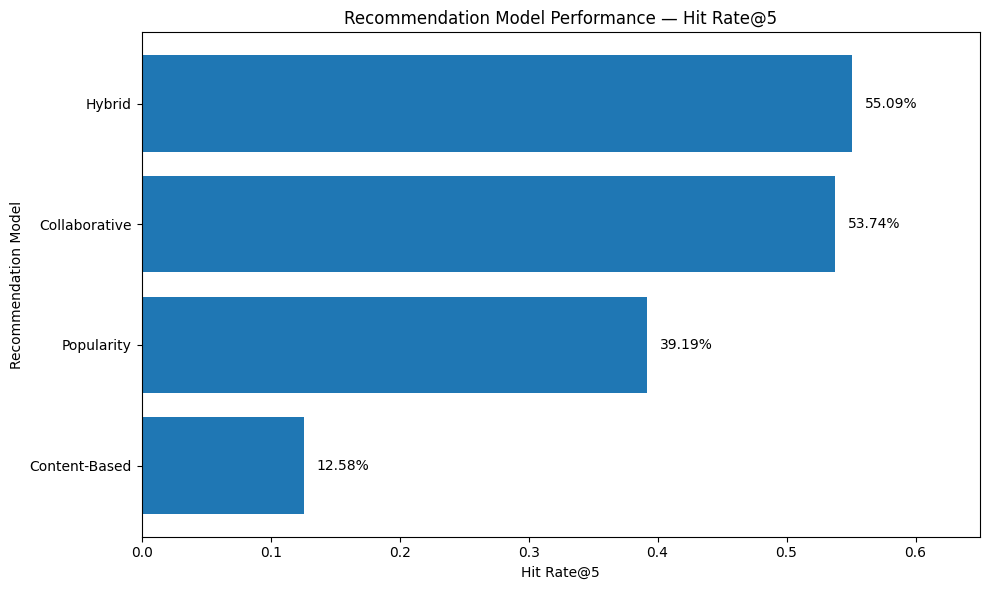

In [106]:
plt.figure(figsize=(10, 6))

plot_data = final_recommendation_metrics.sort_values(
    "Hit_Rate@5",
    ascending=True
)

plt.barh(
    plot_data["Model"],
    plot_data["Hit_Rate@5"]
)

plt.xlabel("Hit Rate@5")
plt.ylabel("Recommendation Model")
plt.title(
    "Recommendation Model Performance — Hit Rate@5"
)

plt.xlim(0, 0.65)

for i, value in enumerate(
    plot_data["Hit_Rate@5"]
):
    plt.text(
        value + 0.01,
        i,
        f"{value:.2%}",
        va="center"
    )

plt.tight_layout()
plt.show()